# Code Predict


In [23]:
import pandas as pd
import joblib

# =====================
# PATH CONFIG
# =====================
DATA_INPUT_PATH = "data_cut.csv"
MODEL_PATH = "xgboost_final.pkl"
THRESHOLD_PATH = "xgb_best_threshold.pkl"
OUTPUT_PATH = "prediction_output.csv"


# =====================
# PREPROCESS (STATELESS)
# =====================
import numpy as np

def preprocess_for_predict(df):
    df = df.copy()

    # -----------------
    # CLEANING
    # -----------------
    df = df.dropna(subset=["newbalanceDest"])

    if "isFraud" in df.columns:
        df = df.drop(columns=["isFraud"])

    df = df.drop(
        columns=["nameOrig", "isFlaggedFraud"],
        errors="ignore"
    )

    # -----------------
    # FEATURE ENGINEERING
    # -----------------

    # NEW: log amount (BẮT BUỘC)
    df["log_amount"] = np.log1p(df["amount"])

    df["balance_diff"] = (
        df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
    )

    df["errorBalanceDest"] = (
        df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]
    )

    df["hour"] = df["step"] % 24
    df["day"] = df["step"] // 24

    df["isMerchant"] = (
        df["nameDest"]
        .astype(str)
        .str.startswith("M")
        .astype(int)
    )

    if "isCustomerDest" not in df.columns:
        df["isCustomerDest"] = 1

    df["amount_ratio_org"] = df["amount"] / (df["oldbalanceOrg"] + 1)
    df["amount_ratio_dest"] = df["amount"] / (df["oldbalanceDest"] + 1)

    df["flag_zero_org"] = (df["oldbalanceOrg"] == 0).astype(int)
    df["flag_zero_dest"] = (df["oldbalanceDest"] == 0).astype(int)

    # KHÔNG one-hot
    # KHÔNG scale
    # GIỮ column "type"

    return df



# =====================
# LOAD DATA
# =====================
df_raw = pd.read_csv(DATA_INPUT_PATH)
X_pred = preprocess_for_predict(df_raw)


# =====================
# LOAD MODEL
# =====================
model = joblib.load(MODEL_PATH)


# =====================
# LOAD & EXTRACT THRESHOLD
# =====================
threshold_obj = joblib.load(THRESHOLD_PATH)

if isinstance(threshold_obj, dict):
    # ưu tiên key phổ biến
    if "best_threshold" in threshold_obj:
        threshold = float(threshold_obj["best_threshold"])
    elif "threshold" in threshold_obj:
        threshold = float(threshold_obj["threshold"])
    else:
        raise ValueError(
            f"Threshold dict keys not recognized: {threshold_obj.keys()}"
        )
else:
    threshold = float(threshold_obj)


# =====================
# PREDICTION
# =====================
fraud_proba = model.predict_proba(X_pred)[:, 1]
fraud_flag = (fraud_proba >= threshold).astype(int)


# =====================
# OUTPUT
# =====================
output = df_raw.copy()
output["fraud_probability"] = fraud_proba
output["fraud_flag"] = fraud_flag

output.to_csv(OUTPUT_PATH, index=False)

print("Predict completed successfully.")
print(f"Output saved to: {OUTPUT_PATH}")
print(f"Threshold used: {threshold}")


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.7.0 when using version 1.6.1. This might lead to breaking code o

Predict completed successfully.
Output saved to: prediction_output.csv
Threshold used: 0.8257251381874084


# Tỉ lệ gian lận

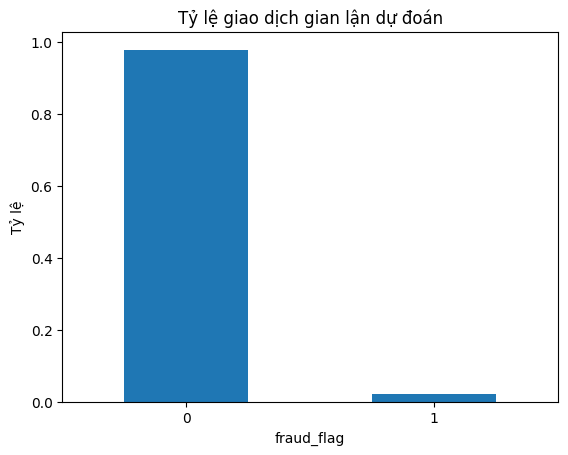

In [18]:
import matplotlib.pyplot as plt

fraud_rate = output["fraud_flag"].value_counts(normalize=True)

plt.figure()
fraud_rate.plot(kind="bar")
plt.title("Tỷ lệ giao dịch gian lận dự đoán")
plt.ylabel("Tỷ lệ")
plt.xticks(rotation=0)
plt.show()


In [22]:
fraud_rate = output["fraud_flag"].mean() * 100

print(f"Tỷ lệ giao dịch bị gắn cờ gian lận: {fraud_rate:.2f}%")


Tỷ lệ giao dịch bị gắn cờ gian lận: 2.10%
Số giao dịch bị gắn cờ: 210/10000


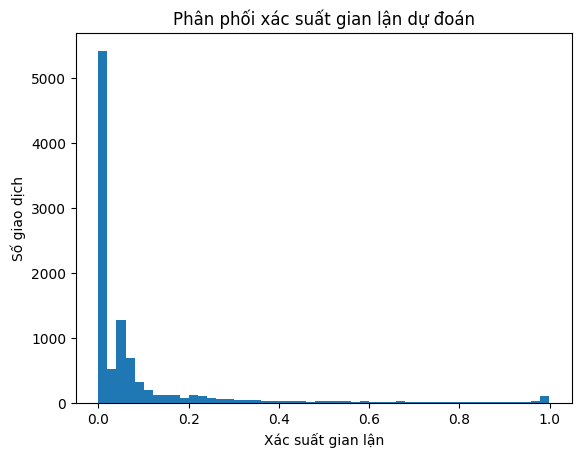

In [24]:
plt.figure()
plt.hist(output["fraud_probability"], bins=50)
plt.xlabel("Xác suất gian lận")
plt.ylabel("Số giao dịch")
plt.title("Phân phối xác suất gian lận dự đoán")
plt.show()
